In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

nav = pd.read_csv("../data/processed/cleaned_nav_history.csv")
investor = pd.read_csv("../data/processed/cleaned_investor_transactions.csv")
scheme = pd.read_csv("../data/processed/cleaned_scheme_performance.csv")

nav["date"] = pd.to_datetime(nav["date"])
investor["transaction_date"] = pd.to_datetime(
    investor["transaction_date"]
)

In [8]:
var_results = []

for code, group in nav.groupby("amfi_code"):

    returns = (
        group["nav"]
        .pct_change()
        .dropna()
    )

    var_95 = np.percentile(
        returns,
        5
    )

    cvar_95 = returns[
        returns <= var_95
    ].mean()

    var_results.append(
        [code, var_95, cvar_95]
    )

var_cvar_df = pd.DataFrame(
    var_results,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

var_cvar_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


var_results = []

for code, group in nav.groupby("amfi_code"):

    returns = (
        group["nav"]
        .pct_change()
        .dropna()
    )

    var_95 = np.percentile(
        returns,
        5
    )

    cvar_95 = returns[
        returns <= var_95
    ].mean()

    var_results.append(
        [code, var_95, cvar_95]
    )

var_cvar_df = pd.DataFrame(
    var_results,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

var_cvar_df.head()

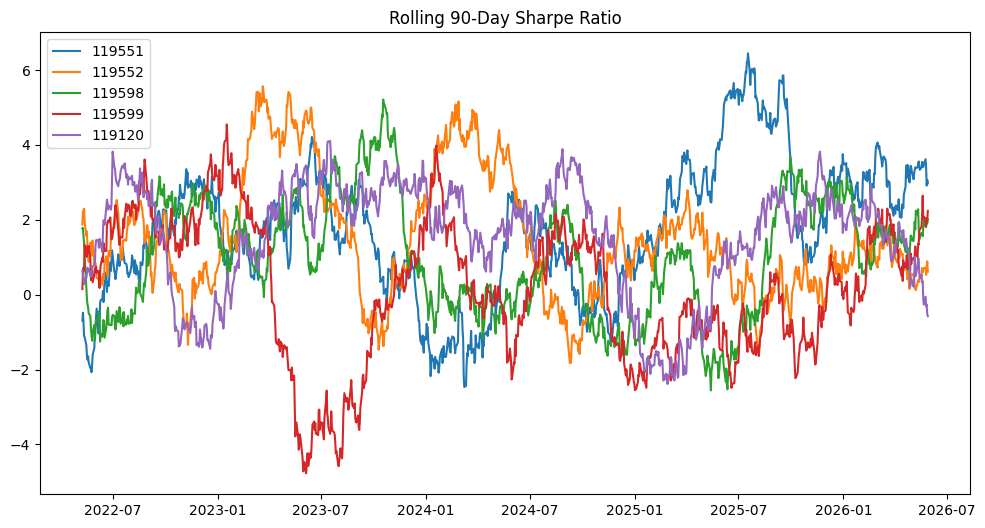

In [9]:
risk_free_rate = 0.065

plt.figure(figsize=(12,6))

top_funds = nav["amfi_code"].unique()[:5]

for code in top_funds:

    fund = nav[
        nav["amfi_code"] == code
    ].copy()

    fund["return"] = (
        fund["nav"]
        .pct_change()
    )

    rolling_sharpe = (
        fund["return"]
        .rolling(90)
        .mean()
        /
        fund["return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        fund["date"],
        rolling_sharpe,
        label=str(code)
    )

plt.legend()
plt.title("Rolling 90-Day Sharpe Ratio")
plt.show()

In [10]:
investor["cohort_year"] = (
    investor.groupby("investor_id")
    ["transaction_date"]
    .transform("min")
    .dt.year
)

cohort_summary = (
    investor
    .groupby("cohort_year")
    .agg(
        avg_sip_amount=("amount_inr","mean"),
        total_invested=("amount_inr","sum")
    )
)

cohort_summary

,avg_sip_amount,total_invested
cohort_year,,
2024,107422.541832,3491125187
2025,109158.577061,30455243


In [11]:
sip = investor.copy()

sip = sip.sort_values(
    ["investor_id",
     "transaction_date"]
)

sip["gap_days"] = (
    sip.groupby("investor_id")
    ["transaction_date"]
    .diff()
    .dt.days
)

risk_investors = (
    sip.groupby("investor_id")
    ["gap_days"]
    .mean()
    .reset_index()
)

risk_investors["status"] = np.where(
    risk_investors["gap_days"] > 35,
    "At Risk",
    "Active"
)

risk_investors.head()

,investor_id,gap_days,status
0,INV000001,38.000,At Risk
1,INV000002,82.800,At Risk
2,INV000003,238.000,At Risk
3,INV000004,53.375,At Risk
4,INV000005,52.000,At Risk


In [12]:
var_cvar_df.to_csv(
    "../data/processed/var_cvar_report.csv",
    index=False
)

print("Day 6 files saved successfully!")

Day 6 files saved successfully!
